Cleaned data. Total rows: 30631
Starting vectorization (this may take a moment)...
Vectorization complete.
Starting model training (XGBoost)...
Model training complete.

--- Model Performance Metrics (XGBoost) ---
Accuracy:   99.56%
Precision:  0.998
Recall:     0.990
F1-Score:   0.994

--- Confusion Matrix ---
[[3836    4]
 [  23 2264]]

Generating 'Wow Factor' (SHAP Explainability)...
--- 'WOW' FACTOR GENERATED! ---
Check your folder for the new file: 'shap_summary_plot.png'
This image shows the features that are MOST important to your model.

Saving model and vectorizer to .pkl files...
--- Project Ready for Next Step! ---
You now have 'xgb_model.pkl' and 'vectorizer.pkl'.
You are ready to build the Flask app ('app.py').


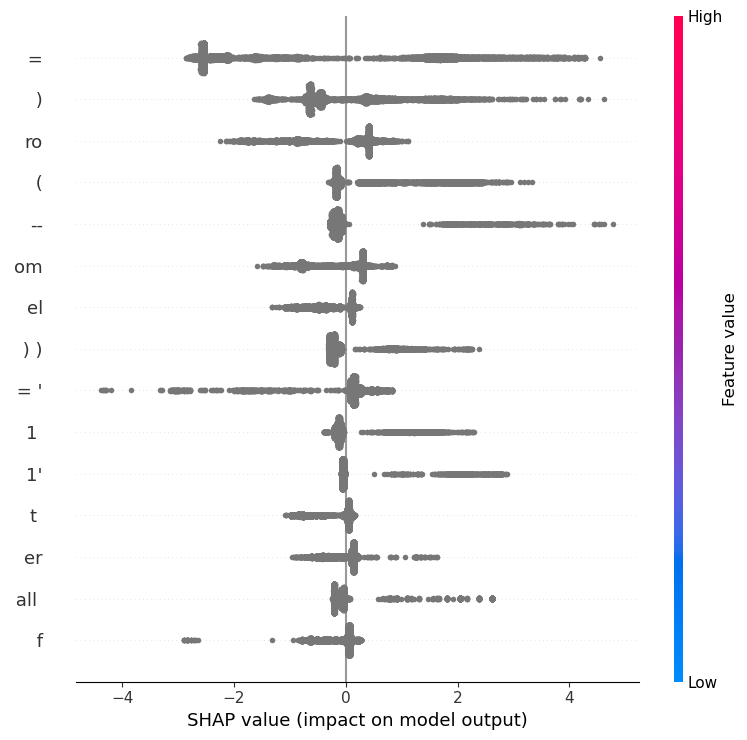

In [ ]:
!pip install xgboost
!pip install shap
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


from xgboost import XGBClassifier  # 1. XGBoost 
import joblib                      # For saving the model
import shap                        # 2. The "Wow Factor"
import matplotlib.pyplot as plt    # For saving the SHAP plot

# --- 1. Load Data ---!
try:
    data = pd.read_csv('sql_injection.csv')
except FileNotFoundError:
    print("FATAL ERROR: 'sql injection dataset.csv' not found.")
    print("Please download the dataset and place it in the same folder.")
    exit()

# --- 2. Clean Data (All Fixes) ---
# Your cleaning logic is good!
data['Sentence'] = data['Sentence'].fillna('')
data.dropna(subset=['Label'], inplace=True)
data['Label'] = pd.to_numeric(data['Label'], errors='coerce')
data.dropna(subset=['Label'], inplace=True)
data['Label'] = data['Label'].astype(int)
data = data[data['Label'].isin([0, 1])]

print(f"Cleaned data. Total rows: {len(data)}")

# --- 3. Define X and Y ---
X = data['Sentence']
Y = data['Label']

# --- 4. Split the data ---
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# --- 5. Vectorize the text (UPGRADED) ---
# This is Objective 1: Implement the Character N-gram pipeline
print("Starting vectorization (this may take a moment)...")
vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(2, 5))
X_train_vectors = vectorizer.fit_transform(X_train)
X_test_vectors = vectorizer.transform(X_test)
print("Vectorization complete.")

# --- 6. Train the model (UPGRADED) ---
# This is Objective 2: Train the XGBoost model
print("Starting model training (XGBoost)...")
model = XGBClassifier(eval_metric='logloss', random_state=42)
model.fit(X_train_vectors, Y_train)
print("Model training complete.")

# --- 7. Evaluate the Model ---
# This is Objective 2: Evaluate the model
Y_pred = model.predict(X_test_vectors)

accuracy = accuracy_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)
matrix = confusion_matrix(Y_test, Y_pred)

print(f"\n--- Model Performance Metrics (XGBoost) ---")
print(f"Accuracy:   {accuracy * 100:.2f}%")
print(f"Precision:  {precision:.3f}")
print(f"Recall:     {recall:.3f}")
print(f"F1-Score:   {f1:.3f}")

print("\n--- Confusion Matrix ---")
print(matrix)

# --- 8. "WOW FACTOR" - Explainable AI (SHAP) ---
# This is Objective 3: Integrate the XAI module
print("\nGenerating 'Wow Factor' (SHAP Explainability)...")
# We use shap.TreeExplainer for our XGBoost model
explainer = shap.TreeExplainer(model)
# Calculate SHAP values for our test set
shap_values = explainer(X_test_vectors)

# Create a summary plot
# This plot shows the top features and their impact
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_vectors, 
                  feature_names=vectorizer.get_feature_names_out(), 
                  max_display=15, 
                  show=False)

# Save the plot to a file
plot_filename = 'shap_summary_plot.png'
plt.savefig(plot_filename, bbox_inches='tight')
print(f"--- 'WOW' FACTOR GENERATED! ---")
print(f"Check your folder for the new file: '{plot_filename}'")
print("This image shows the features that are MOST important to your model.")



# --- 9. Save the Model and Vectorizer for the Web App ---
# This step prepares the files needed for Objective 4
print("\nSaving model and vectorizer to .pkl files...")
joblib.dump(model, 'xgb_model.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')

print("--- Project Ready for Next Step! ---")
print("You now have 'xgb_model.pkl' and 'vectorizer.pkl'.")
print("You are ready to build the Flask app ('app.py').")

In [ ]:
import joblib
import shap
import pandas as pd
from scipy.sparse import issparse

# --- 1. Load the "Brain" and "Explainer" ---
print("Loading model, vectorizer, and explainer...")
try:
    model = joblib.load('xgb_model.pkl')
    vectorizer = joblib.load('vectorizer.pkl')
except FileNotFoundError:
    print("FATAL ERROR: '.pkl' files not found.")
    print("Please run your training script first to create the model files.")
    exit()

# Re-create the SHAP explainer from the loaded model
explainer = shap.TreeExplainer(model)
print("--- Ready to Explain Queries ---")

def explain_query(query_string):
    """
    Analyzes a single query and prints its prediction and top
    contributing N-grams (features).
    """
    
    # 1. Transform the query using the loaded vectorizer
    query_vector = vectorizer.transform([query_string])
    
    # 2. Get the model's prediction
    prediction = model.predict(query_vector)[0]
    prediction_proba = model.predict_proba(query_vector)[0][1] # Prob of being MALICIOUS
    
    # 3. Get SHAP values
    shap_values = explainer.shap_values(query_vector)
    
    # --- START FIX ---
    # The explainer for binary XGBoost returns a single array (not a list of 2).
    # The 'shap_values' variable is the array we want.
    # The old buggy line 'shap_values_for_class1 = shap_values[1]' is removed.
    shap_values_for_class1 = shap_values
    # --- END FIX ---

    if issparse(shap_values_for_class1):
        shap_values_for_class1 = shap_values_for_class1.toarray()

    # Get all feature names (N-grams) from the vectorizer
    feature_names = vectorizer.get_feature_names_out()
    
    # Create a DataFrame to map N-grams to their SHAP values
    # The [0] here is correct, as it selects the first (and only)
    # query's explanation from the array.
    df = pd.DataFrame({
        'ngram': feature_names,
        'shap_value': shap_values_for_class1[0]
    })
    
    # Filter to only show N-grams that actually had an impact (SHAP value != 0)
    df = df[df['shap_value'] != 0]
    
    # Sort by the absolute impact to see top contributors (positive or negative)
    df['abs_shap'] = df['shap_value'].abs()
    df = df.sort_values(by='abs_shap', ascending=False)

    # 4. Print the results
    result_text = "MALICIOUS" if prediction == 1 else "SAFE"
    print(f"\n--- Analysis for Query: '{query_string}' ---")
    print(f"Overall Prediction: ** {result_text} **")
    print(f"Confidence (Malicious Probability): {prediction_proba * 100:.2f}%")
    
    print("\n--- Top Contributing N-grams ---")
    print("(A positive 'shap_value' pushes the model to 'MALICIOUS')")
    print("(A negative 'shap_value' pushes the model to 'SAFE')")
    
    # Print the top 10 contributing N-grams
    print(df[['ngram', 'shap_value']].head(10).to_string())

# --- 4. Run the Explainer ---
if __name__ == "__main__":
    # Keep asking for queries until the user quits
    print("Type your query and press Enter. (Type 'exit' to quit)")
    
    while True:
        user_query = input("\nEnter query to explain: ")
        
        if user_query.lower() == 'exit':
            break
            
        try:
            explain_query(user_query)
        except Exception as e:
            print(f"An error occurred: {e}")

Loading model, vectorizer, and explainer...
--- Ready to Explain Queries ---
Type your query and press Enter. (Type 'exit' to quit)



Enter query to explain:  '1'='1'



--- Analysis for Query: ''1'='1'' ---
Overall Prediction: ** MALICIOUS **
Confidence (Malicious Probability): 52.05%

--- Top Contributing N-grams ---
(A positive 'shap_value' pushes the model to 'MALICIOUS')
(A negative 'shap_value' pushes the model to 'SAFE')
        ngram  shap_value
51923      1'    2.758441
12532       =   -2.551641
5311        )   -0.642434
208685     ro    0.407123
191148     om    0.298155
5323      ) )   -0.213896
13446    all    -0.210368
40490      --   -0.164584
4878        (   -0.142304
140968     er    0.133427



Enter query to explain:  1='1'



--- Analysis for Query: '1='1'' ---
Overall Prediction: ** MALICIOUS **
Confidence (Malicious Probability): 52.05%

--- Top Contributing N-grams ---
(A positive 'shap_value' pushes the model to 'MALICIOUS')
(A negative 'shap_value' pushes the model to 'SAFE')
        ngram  shap_value
51923      1'    2.758441
12532       =   -2.551641
5311        )   -0.642434
208685     ro    0.407123
191148     om    0.298155
5323      ) )   -0.213896
13446    all    -0.210368
40490      --   -0.164584
4878        (   -0.142304
140968     er    0.133427
